Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [1]:
library(tidymodels)

── Attaching packages ────────────────────────────────────────────────────────────────────────────── tidymodels 1.5.0 ──

✔ broom        1.0.12     ✔ recipes      1.3.2 
✔ dials        1.4.3      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.6.0      ✔ workflows    1.3.0 
✔ parsnip      1.5.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 

── Conflicts ───────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [2]:
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [3]:
diabetes_train |> glimpse()

Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 1, 5, 4, 1, 8, 1, 13, 5, 3, 6, 4, 11, 3, 7…
$ Glucose                  <dbl> 85, 89, 116, 110, 103, 99, 97, 145, 109, 88, …
$ BloodPressure            <dbl> 66, 66, 74, 92, 30, 84, 66, 82, 75, 58, 92, 6…
$ SkinThickness            <dbl> 29, 23, 0, 0, 38, 0, 15, 19, 26, 11, 0, 33, 0…
$ Insulin                  <dbl> 0, 94, 0, 0, 83, 0, 140, 110, 0, 54, 0, 192, …
$ BMI                      <dbl> 26.6, 28.1, 25.6, 37.6, 43.3, 35.4, 23.2, 22.…
$ DiabetesPedigreeFunction <dbl> 0.351, 0.167, 0.201, 0.191, 0.183, 0.388, 0.4…
$ Age                      <dbl> 31, 21, 30, 30, 33, 50, 22, 57, 60, 22, 28, 3…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:**

A binary catagorical variable that only takes a 0 or 1 is suitable for the logistic regression model, and in this case the 'Outcome' column works for this data.

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     |          Plasma Glucose Concentration a 2-hour in an Oral Glucose Tolerance Test (mg/dl).   |
| BMI         |         Body Mass Index (weight in kg/(height in m)^2)    |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

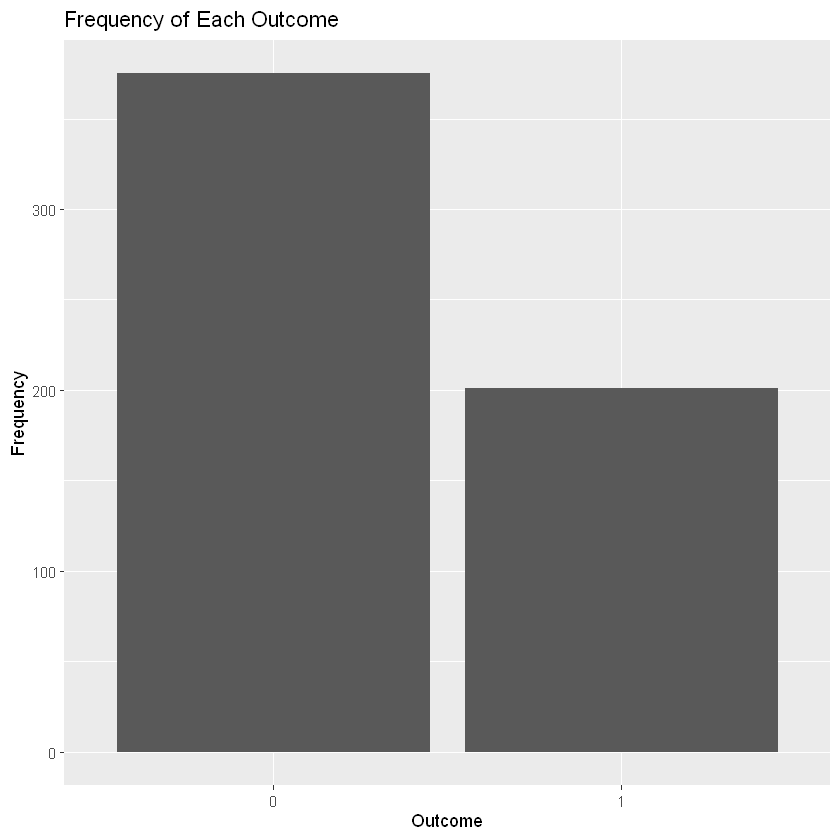

In [4]:
library(ggplot2)

ggplot(diabetes_train, aes(x = factor(Outcome))) +
  geom_bar() +
  labs(
    title = "Frequency of Each Outcome",
    x = "Outcome",
    y = "Frequency"
  )

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:**

No there is not equal counts, the amount of 0's is nearly double the amount of 1's.

Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [5]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,85.0
0,BMI,26.6
0,Glucose,89.0
0,BMI,28.1
0,Glucose,116.0
0,BMI,25.6


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

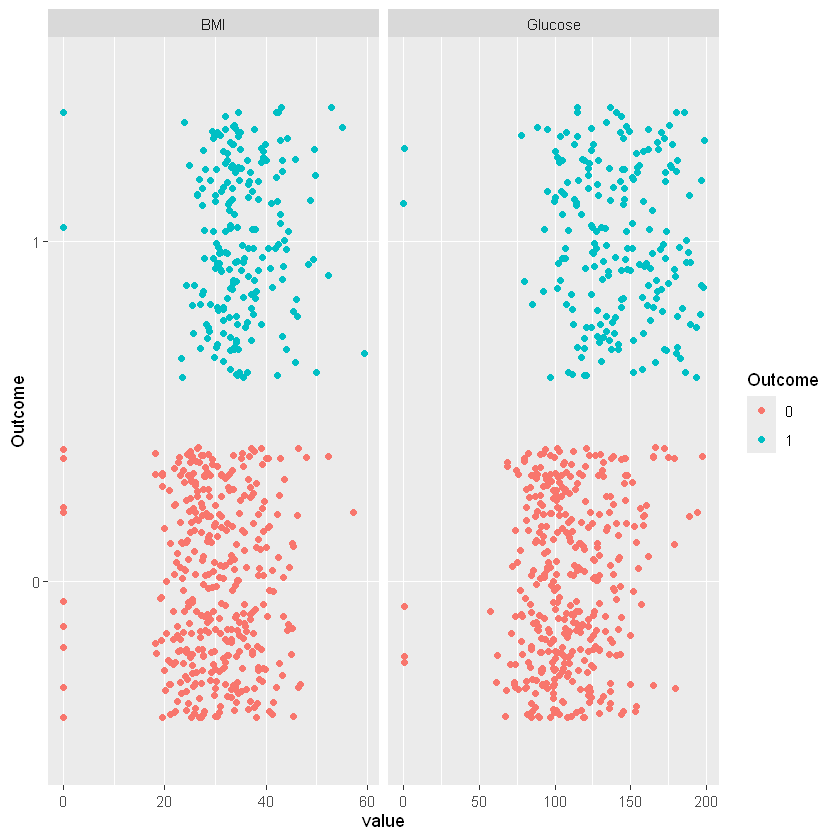

In [6]:
ggplot(plot_df, aes(x = value, y = Outcome, color = Outcome)) +
    geom_jitter() +
    facet_wrap(~name, ncol = 2, scales = "free_x")

❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**

When you remove the 'free_x' scale the scale becomes absolute and is the same for both BMI and Glucose, but since these values are drastically different it makes it hard to see if there is an actual difference in outcome for BMI.

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [10]:
mod <- logistic_reg() |> set_engine("glm")

mod_fit <- mod |> fit(Outcome ~ BMI + Glucose, data = diabetes_train)

Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [12]:
library(broom)

diabetes_test_wPred <- augment(mod_fit, new_data = diabetes_test)

Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [13]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 114  29
         1  11  38

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**

1. The number of individuals with diabetes was 67.
2. Of those 67 that actually had diabetes, 38 were predicted to have diabetes based on the model.
3. Of those predicted to have diabetes, 11 did not actually have diabetes. 